In [8]:
# Environment: ensure numpy<2.4 for SHAP (Numba). Install: pip install -r requirements.txt
import json
import os
import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Must match XGBoost.ipynb so joblib can unpickle model_artifacts.joblib
@dataclass
class Scalers:
    x_scaler: StandardScaler
    y_scaler: StandardScaler

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP unavailable (e.g. numpy>=2.4). Install: pip install 'numpy<2.4' shap")

In [9]:
# Best model path (holdout | window_flatten | win_16 | high_none, low_0.3)
BEST_OUT_DIR = "../3. XGBoost Training/xgb_hyangrin_results/holdout/window_flatten/win_16/high_none_low_0.3"
SAVE_DIR = "."  # Save all outputs to current directory
INPUT_EXCEL = os.path.join("..", "2. PV_Power_Data", "Hyanglin_dataset_merged_daytime_5_19.xlsx")
TARGET_COL = "output_power"
YEAR_FIXED = 2024
TEST_MONTHS = {11, 12}
WINDOW_LENGTH = 16

In [10]:
# Minimal pipeline to rebuild test set (chronological order, one-step target, window flatten)
def _build_datetime(df):
    req = {"month", "day", "hour", "minute"}
    if not req.issubset(df.columns):
        raise KeyError(f"Required columns: {sorted(req)}")
    return pd.to_datetime(
        {"year": YEAR_FIXED, "month": df["month"].astype(int), "day": df["day"].astype(int),
         "hour": df["hour"].astype(int), "minute": df["minute"].astype(int)},
        errors="coerce",
    )

def _chronological_sort(df):
    df = df.copy()
    df["datetime"] = _build_datetime(df)
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
    return df

def _shift_target(df, target_col):
    df = df.copy()
    df["y_next"] = df[target_col].shift(-1)
    return df.dropna(subset=["y_next"]).reset_index(drop=True)

def _window_flatten(df, feature_cols, window_len):
    X_raw = df[feature_cols].to_numpy(dtype=float)
    y_raw = df["y_next"].to_numpy(dtype=float)
    n = len(df)
    if n <= window_len:
        raise ValueError("Insufficient samples for window length.")
    X_list, y_list, meta_rows = [], [], []
    for t in range(window_len - 1, n):
        window = X_raw[t - window_len + 1 : t + 1, :]
        X_list.append(window.reshape(-1))
        y_list.append(y_raw[t])
        meta_rows.append(df.iloc[t][["datetime", "month", "day", "hour", "minute"]].to_dict())
    return np.asarray(X_list, float), np.asarray(y_list, float), pd.DataFrame(meta_rows)

def _test_mask(meta):
    return meta["month"].astype(int).isin(TEST_MONTHS).to_numpy()

In [11]:
# Load artifacts and feature selection; rebuild full-dataset design matrix for SHAP
artifacts_path = os.path.join(BEST_OUT_DIR, "model_artifacts.joblib")
artifacts = joblib.load(artifacts_path)
model = artifacts["model"]
scalers = artifacts["scalers"]

with open(os.path.join(BEST_OUT_DIR, "feature_selection.json")) as f:
    fs_info = json.load(f)
selected_features = fs_info["selected_features"]

df_base = _shift_target(_chronological_sort(pd.read_excel(INPUT_EXCEL)), TARGET_COL)
X, y, meta = _window_flatten(df_base, selected_features, WINDOW_LENGTH)
X_all_s = scalers.x_scaler.transform(X)

# Feature names for flattened window (t-3, t-2, t-1, t)
n_base = len(selected_features)
feature_names = [f"{f}_t-{WINDOW_LENGTH - 1 - k}" for k in range(WINDOW_LENGTH) for f in selected_features]

Saved: ./feature_importance.csv


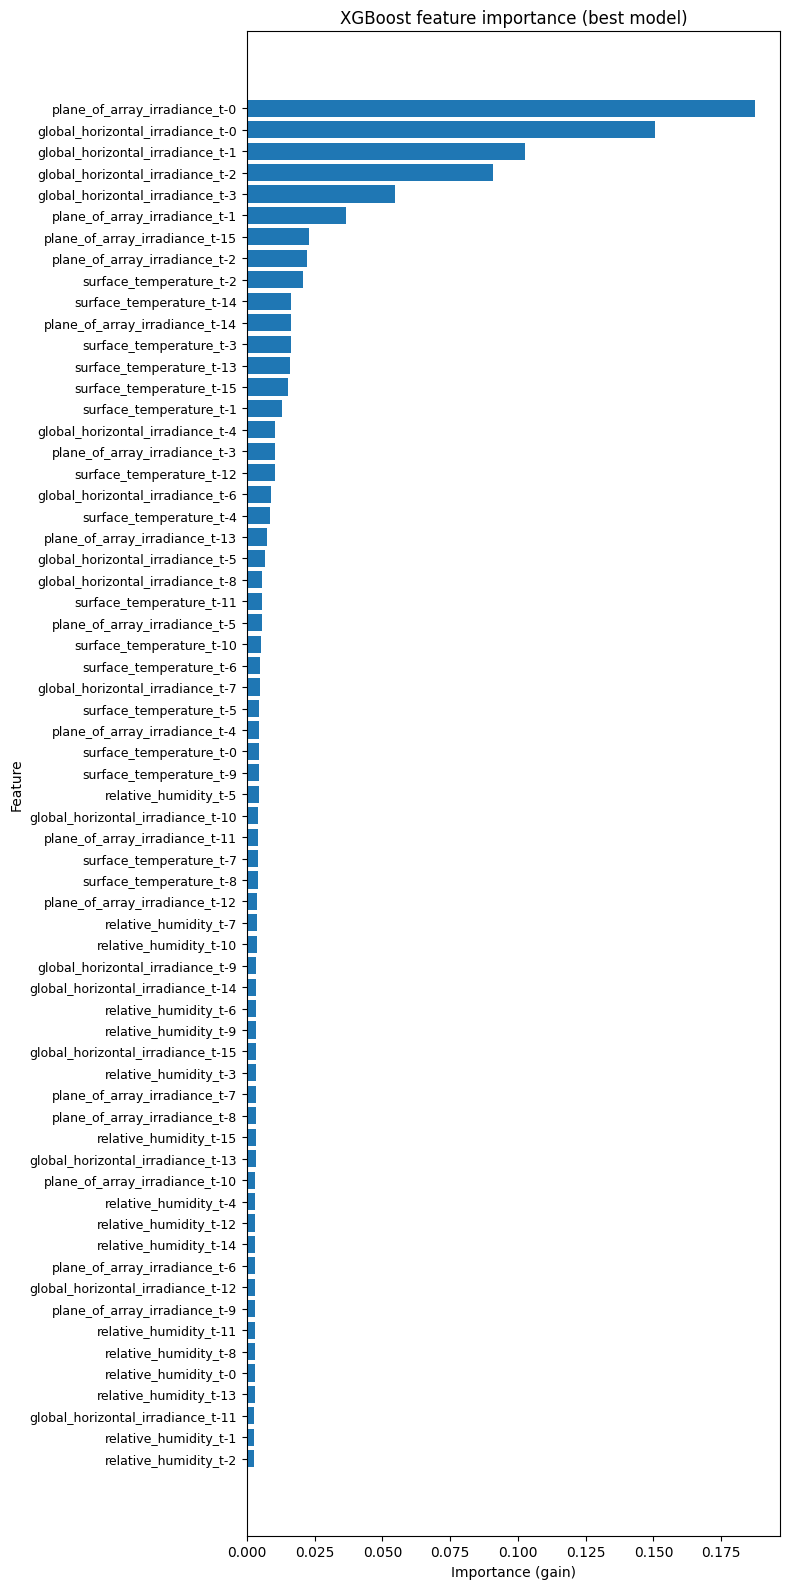

In [12]:
# Feature importance (gain)
imp = model.feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)
fi_path = os.path.join(SAVE_DIR, "feature_importance.csv")
fi_df.to_csv(fi_path, index=False)
print(f"Saved: {fi_path}")

fig, ax = plt.subplots(figsize=(8, max(6, len(feature_names) * 0.25)))
ax.barh(range(len(fi_df)), fi_df["importance"].values, align="center")
ax.set_yticks(range(len(fi_df)))
ax.set_yticklabels(fi_df["feature"].values, fontsize=9)
ax.set_xlabel("Importance (gain)")
ax.set_ylabel("Feature")
ax.set_title("XGBoost feature importance (best model)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Saved: shap_importance.csv, shap_values.npz


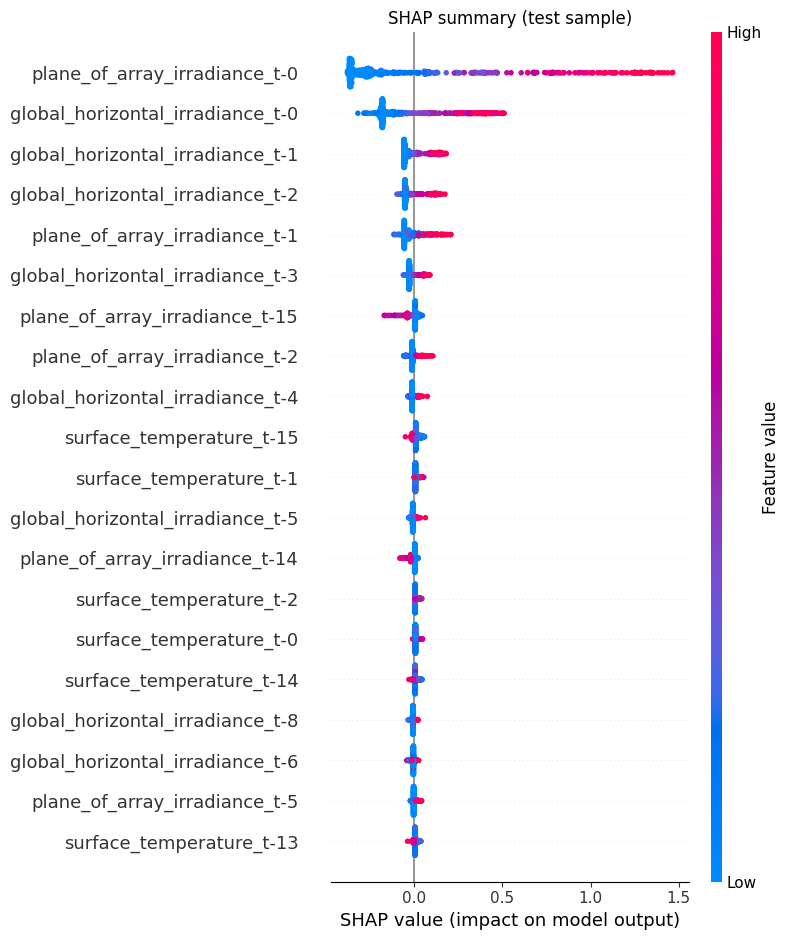

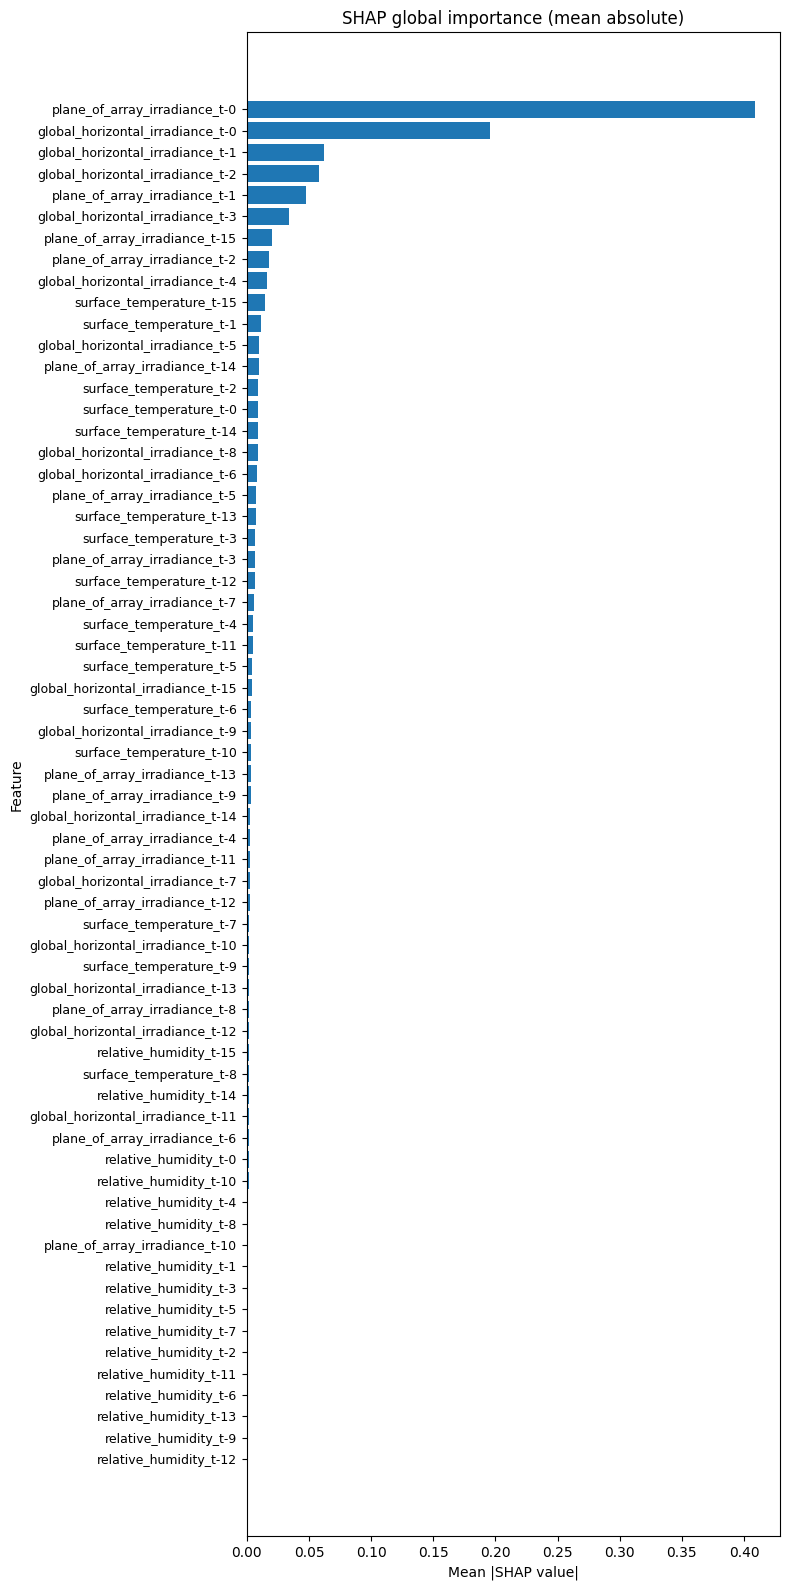

Done: feature importance and SHAP outputs saved to current directory.


In [13]:
# SHAP: TreeExplainer on 1000 random samples from the full dataset (train+val+test)
if not HAS_SHAP:
    print("SHAP skipped (import failed).")
else:
    max_shap_samples = 1000
    n_all = X_all_s.shape[0]
    if n_all > max_shap_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n_all, size=max_shap_samples, replace=False)
        X_shap = X_all_s[idx]
        X_shap_raw = X[idx]
    else:
        X_shap = X_all_s
        X_shap_raw = X

    explainer = shap.TreeExplainer(model, feature_names=feature_names)
    shap_values = explainer.shap_values(X_shap)

    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": shap_importance}).sort_values("mean_abs_shap", ascending=False)
    shap_df.to_csv(os.path.join(SAVE_DIR, "shap_importance.csv"), index=False)
    np.savez(os.path.join(SAVE_DIR, "shap_values.npz"), shap_values=shap_values, feature_names=feature_names, X_sample=X_shap, X_sample_raw=X_shap_raw)
    print(f"Saved: shap_importance.csv, shap_values.npz")

    # Use unscaled features (X_shap_raw) for display so axis and colorbar show interpretable values
    plt.figure(figsize=(10, max(6, len(feature_names) * 0.3)))
    shap.summary_plot(shap_values, X_shap_raw, feature_names=feature_names, show=False, max_display=min(20, len(feature_names)))
    plt.title("SHAP summary (test sample)")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(8, max(6, len(shap_df) * 0.25)))
    ax.barh(range(len(shap_df)), shap_df["mean_abs_shap"].values, align="center")
    ax.set_yticks(range(len(shap_df)))
    ax.set_yticklabels(shap_df["feature"].values, fontsize=9)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Feature")
    ax.set_title("SHAP global importance (mean absolute)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "shap_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Done: feature importance and SHAP outputs saved to current directory.")

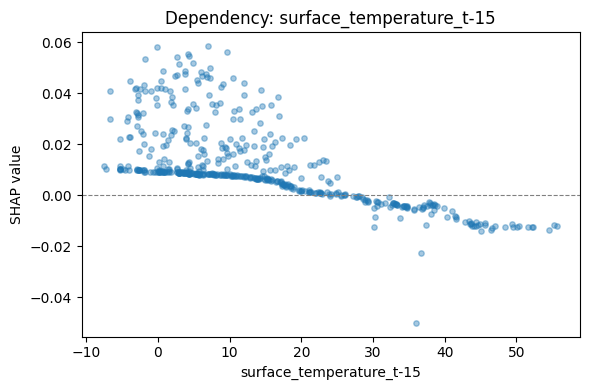

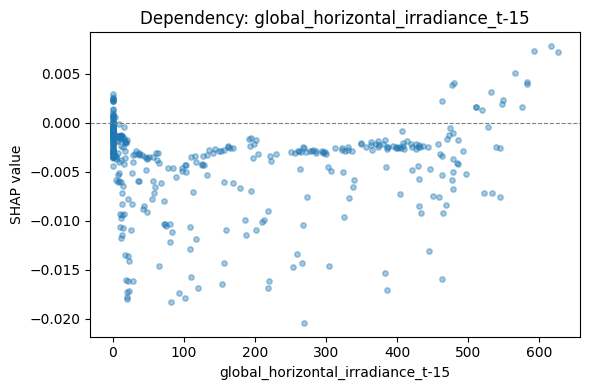

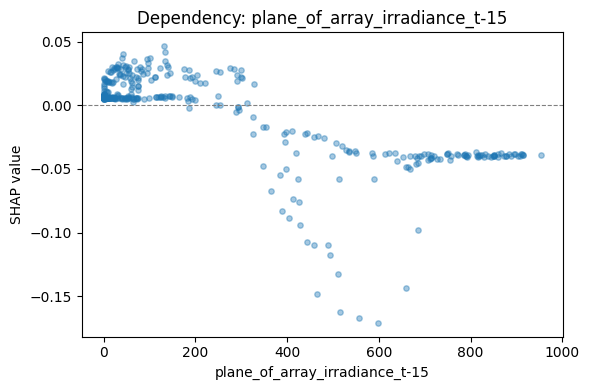

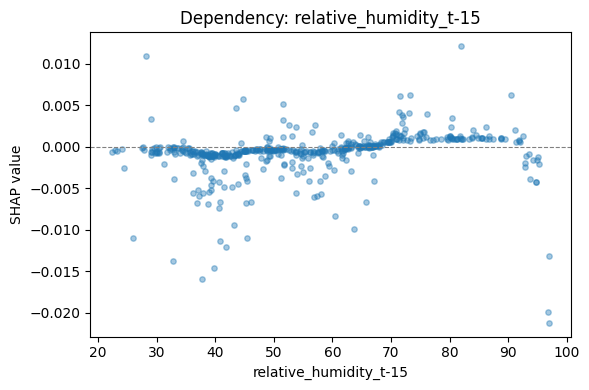

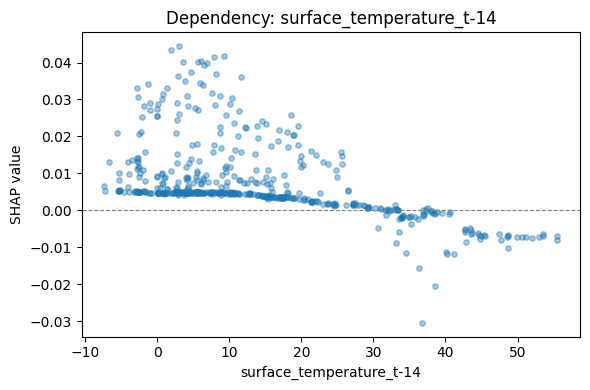

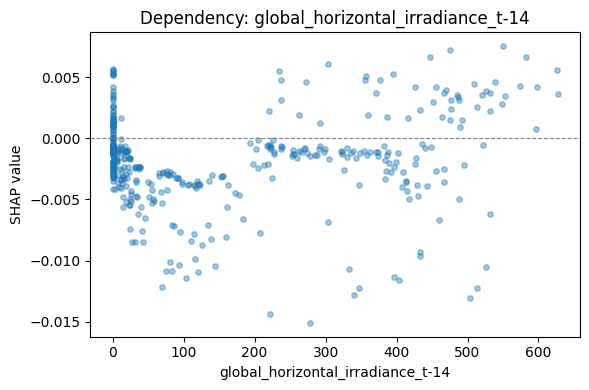

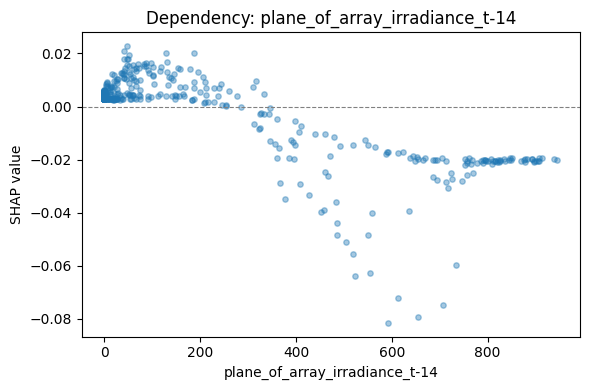

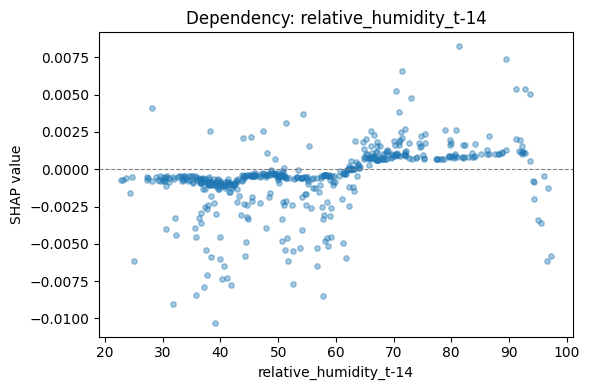

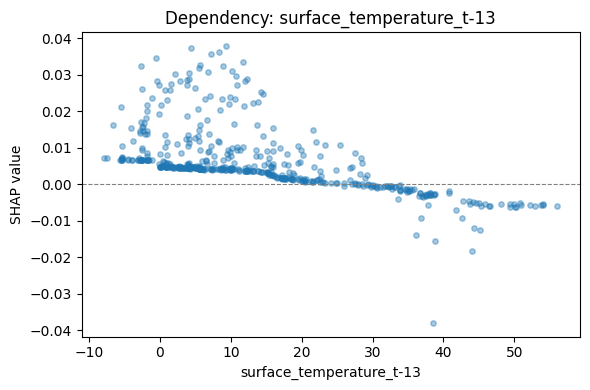

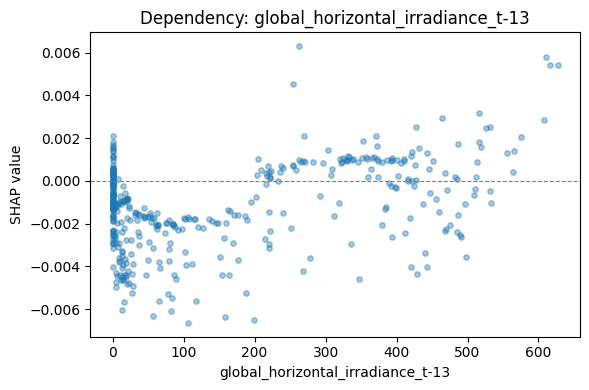

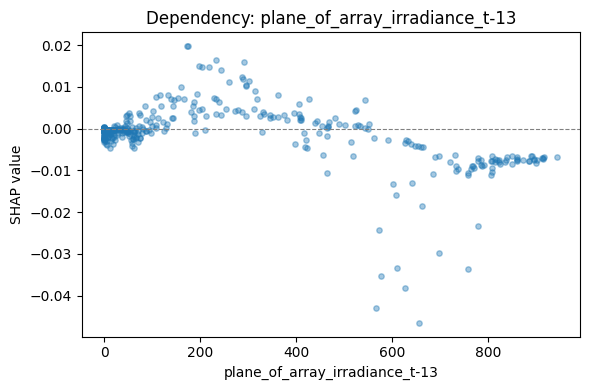

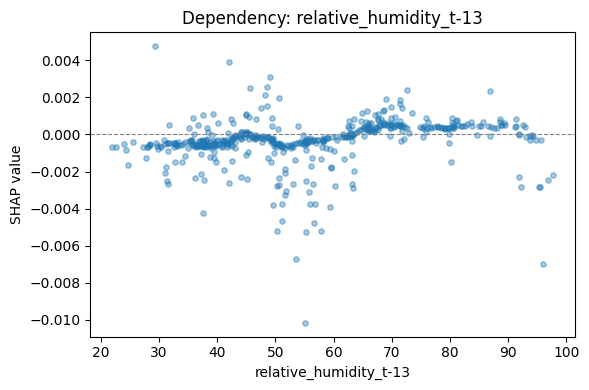

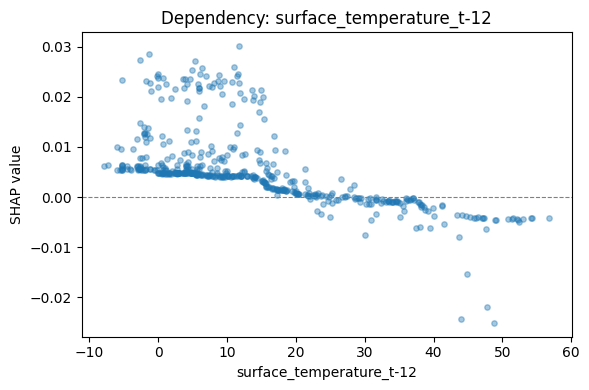

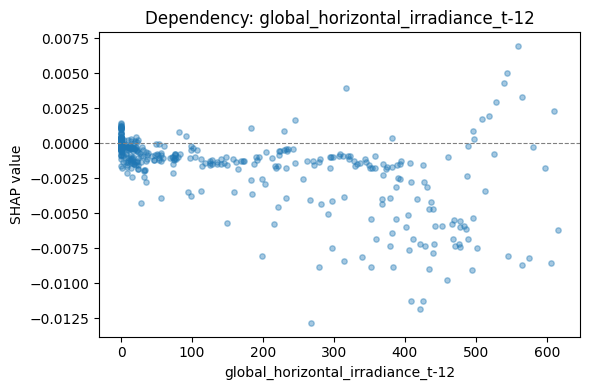

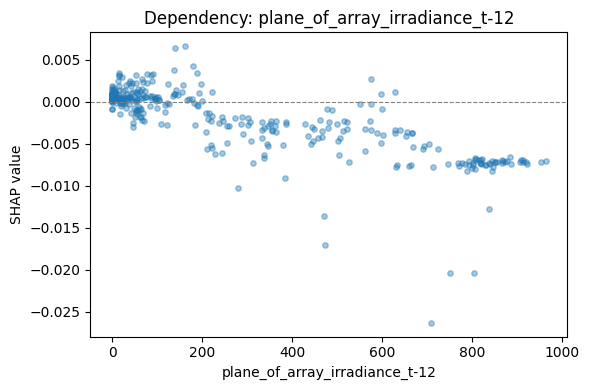

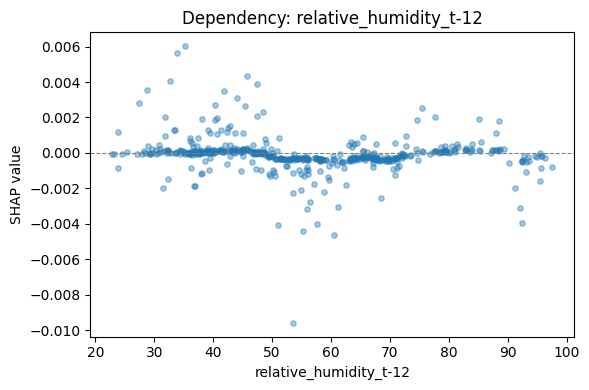

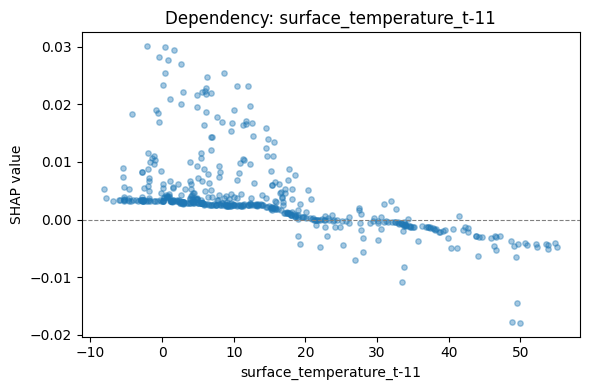

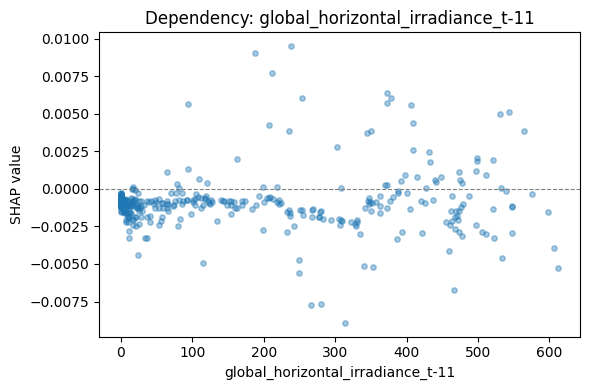

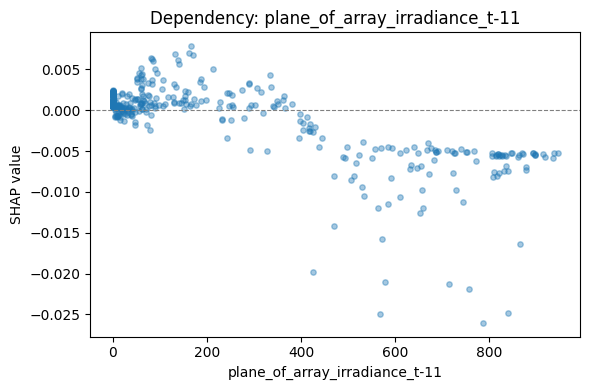

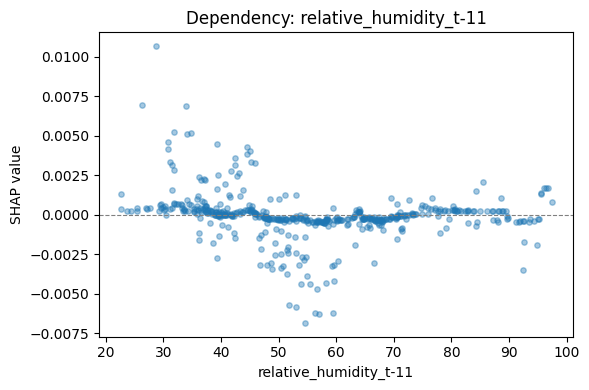

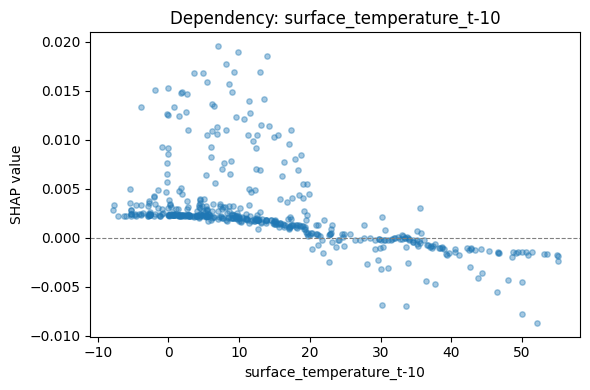

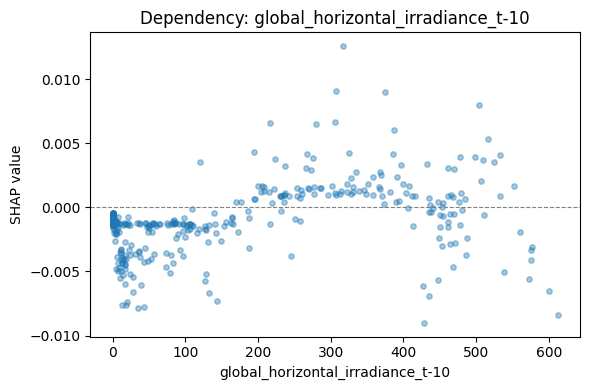

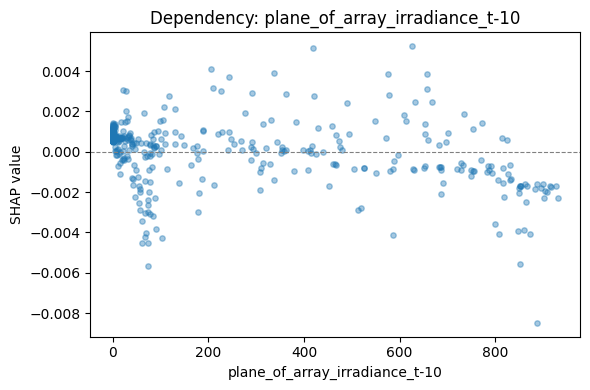

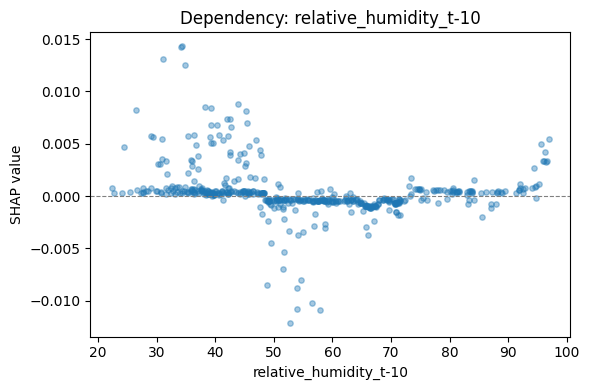

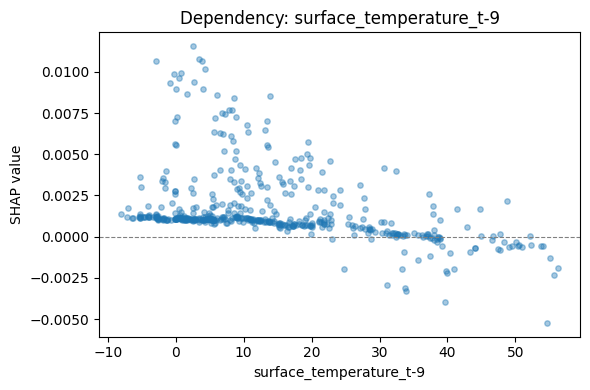

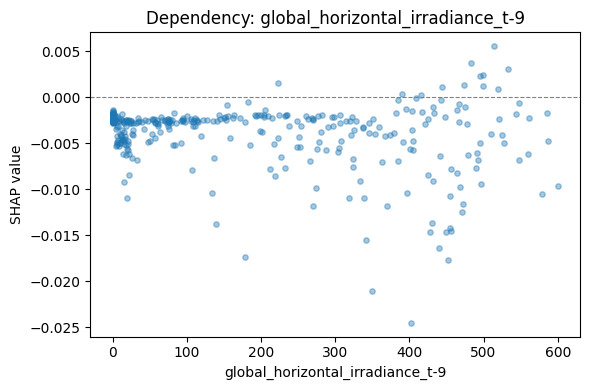

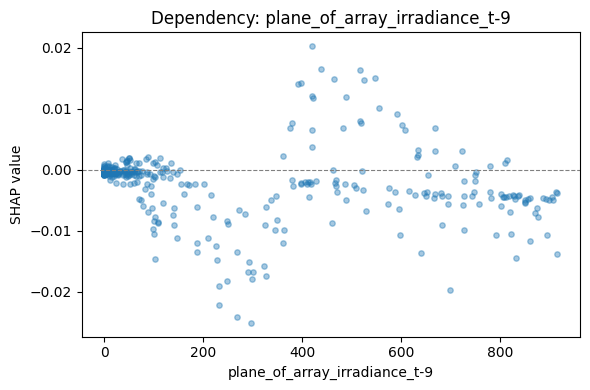

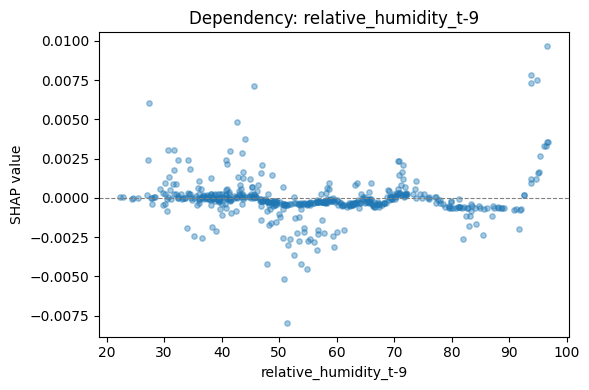

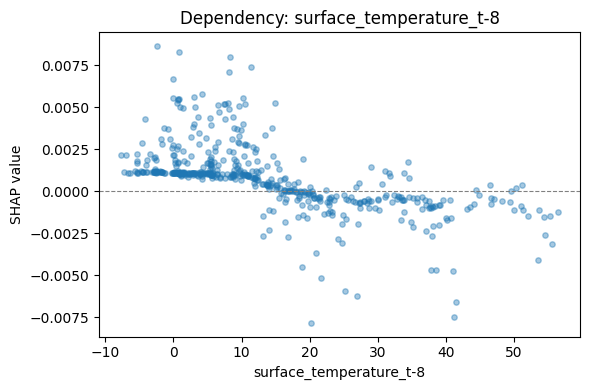

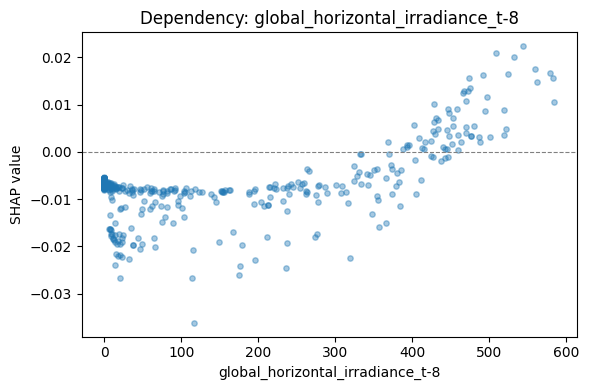

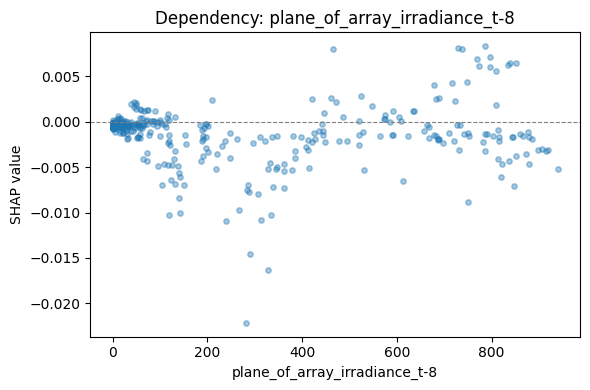

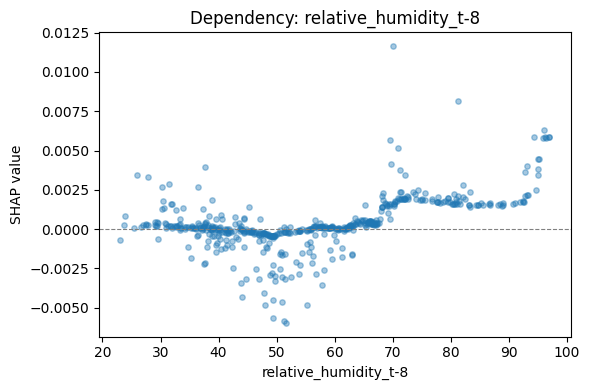

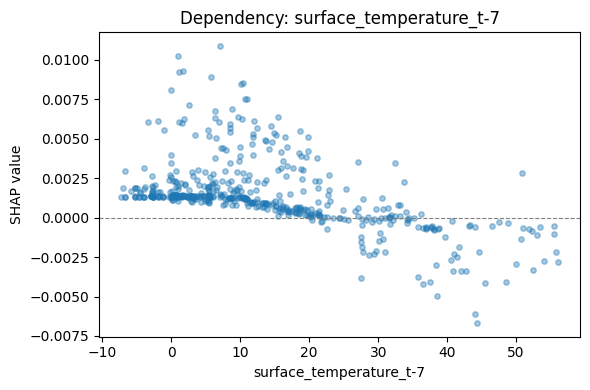

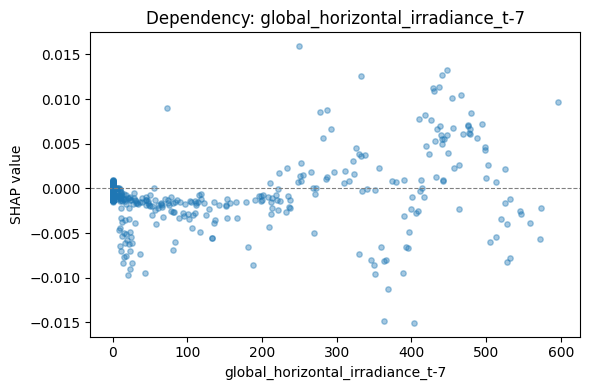

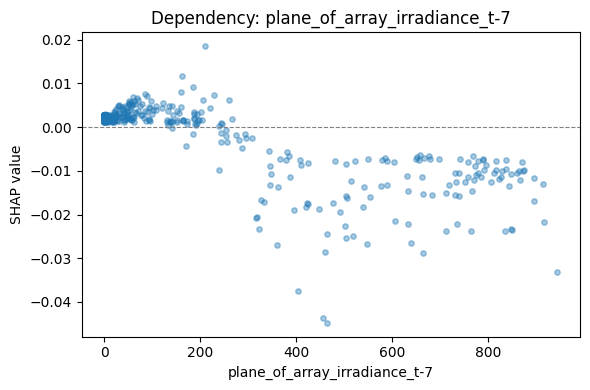

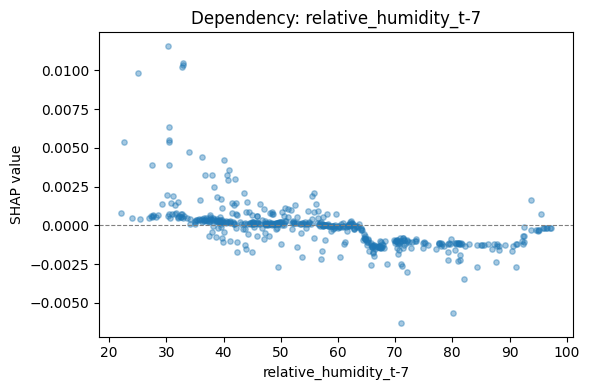

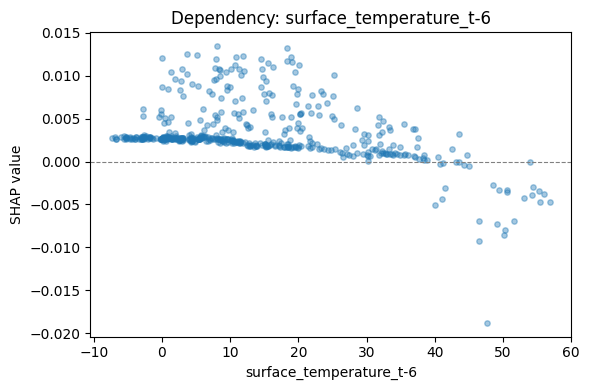

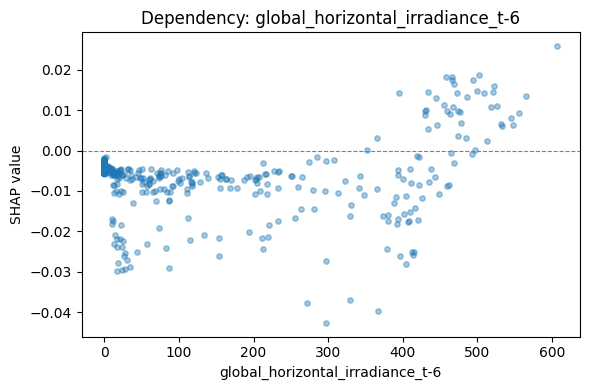

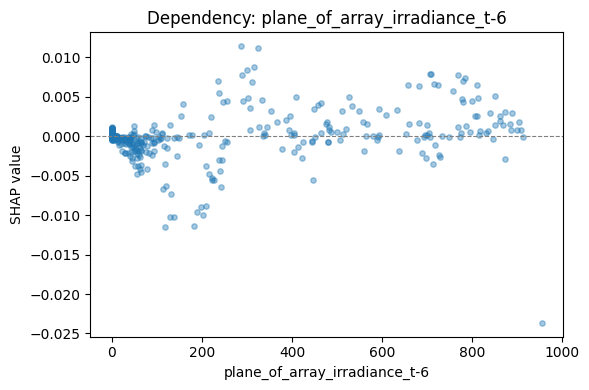

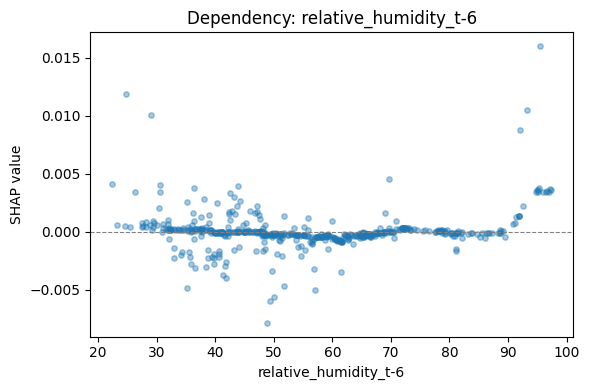

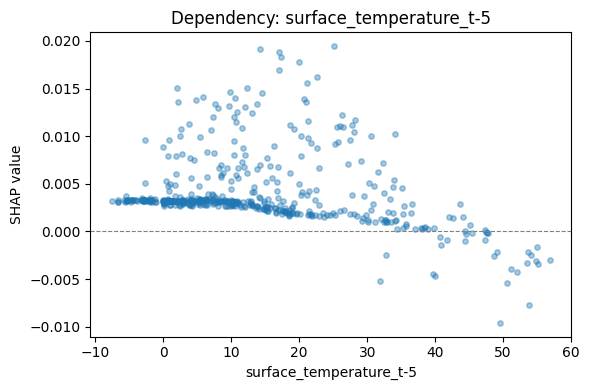

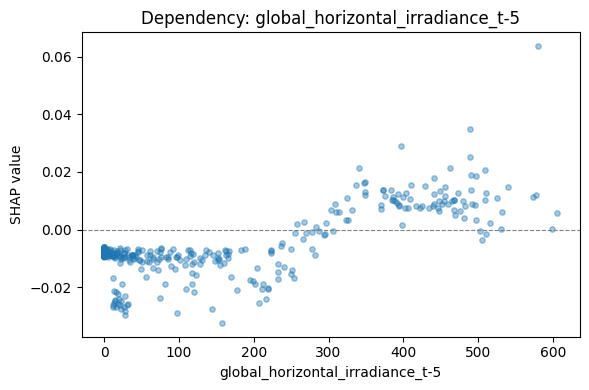

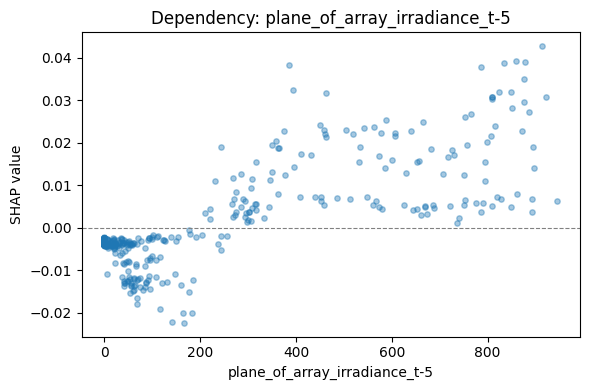

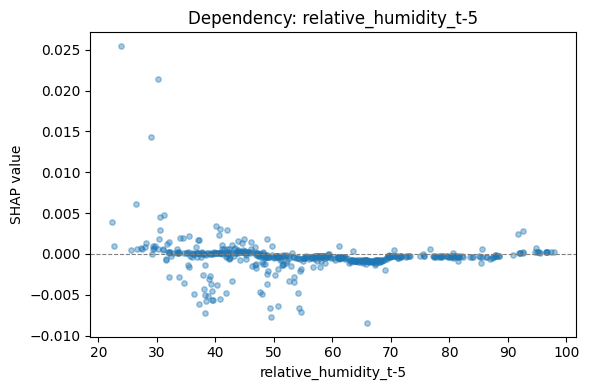

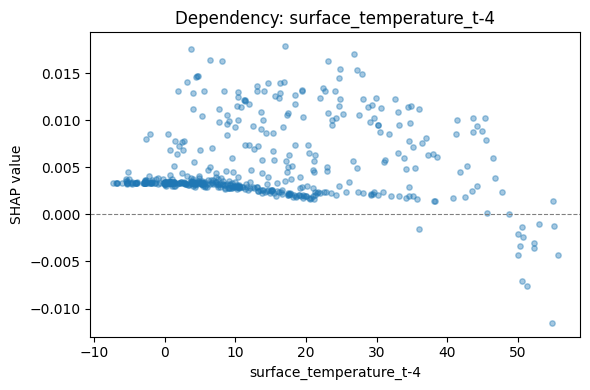

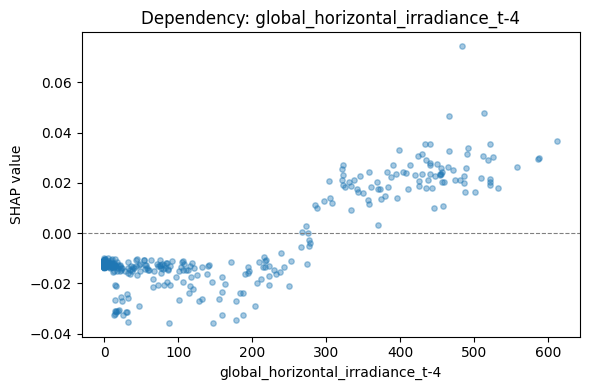

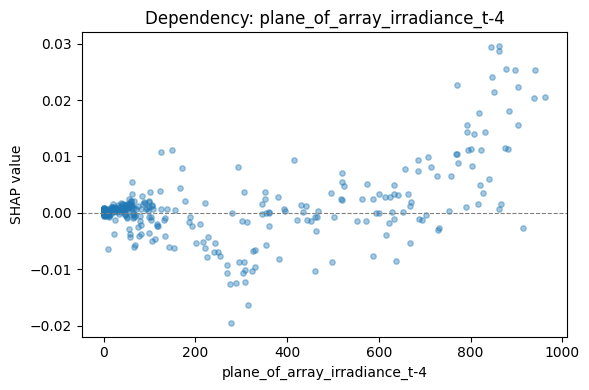

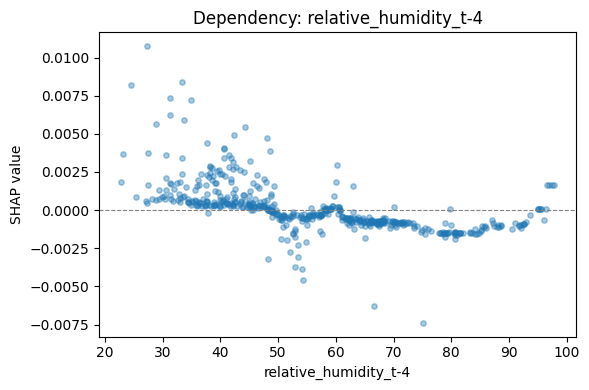

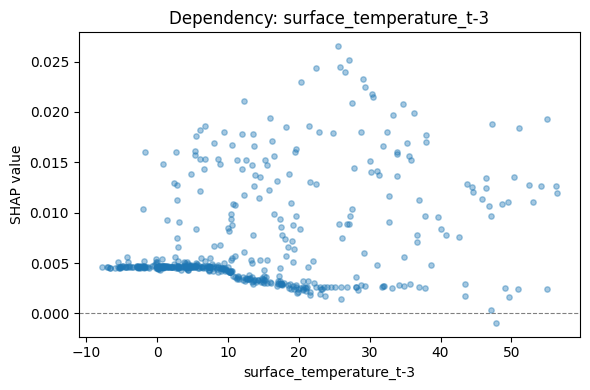

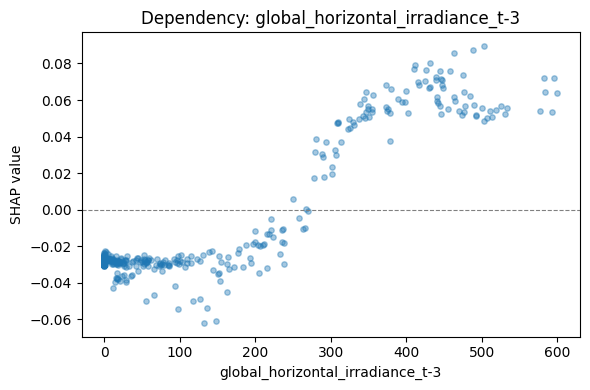

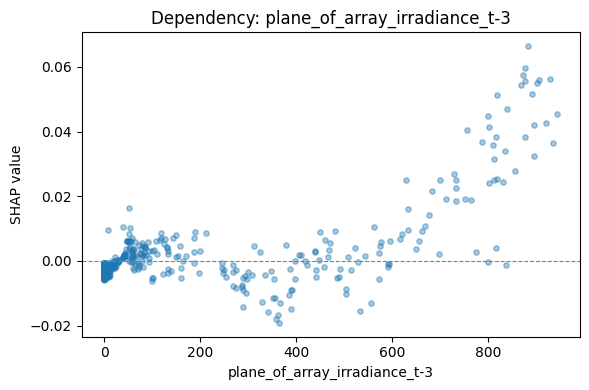

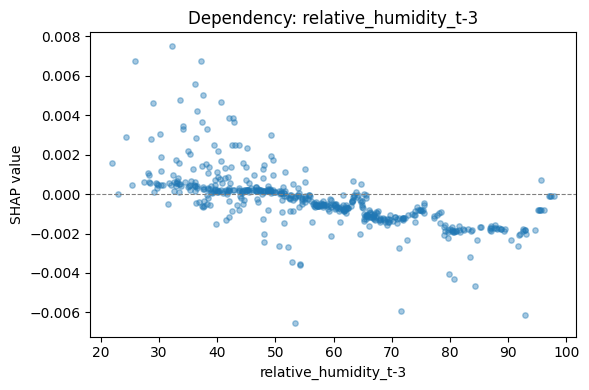

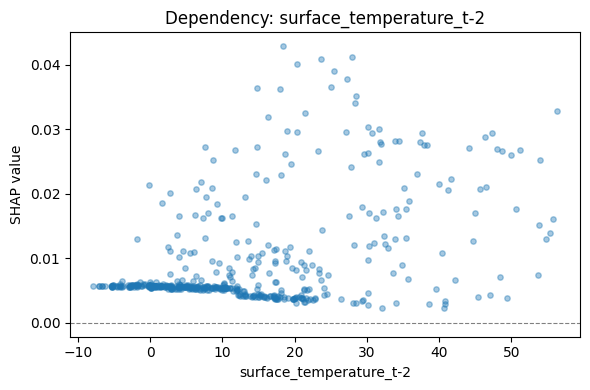

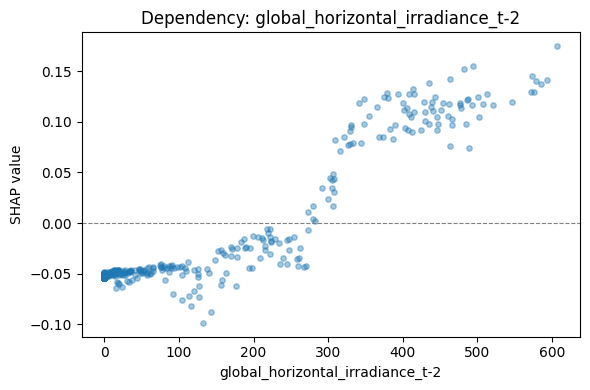

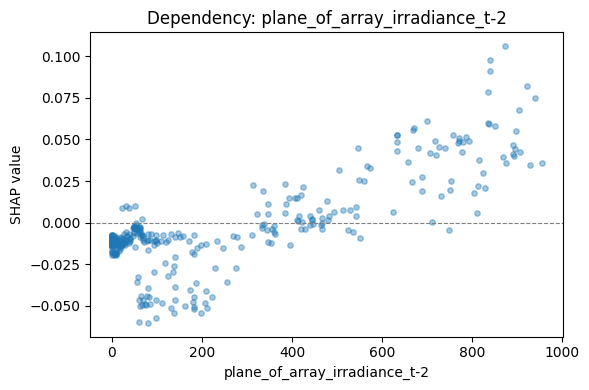

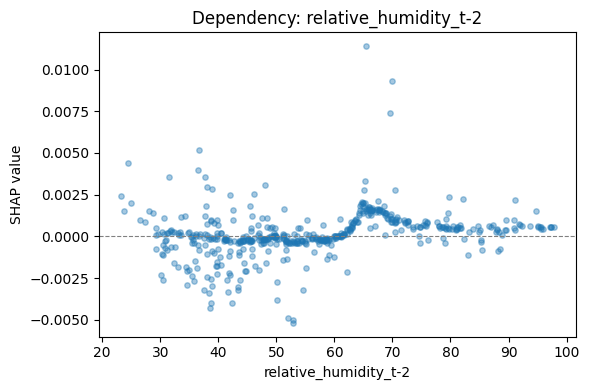

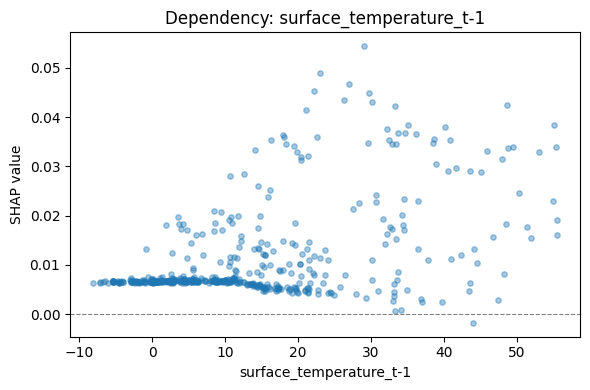

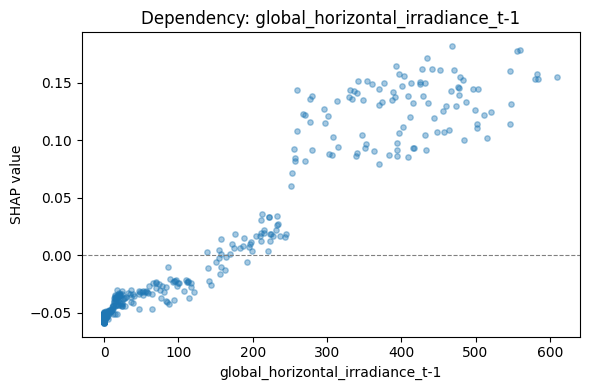

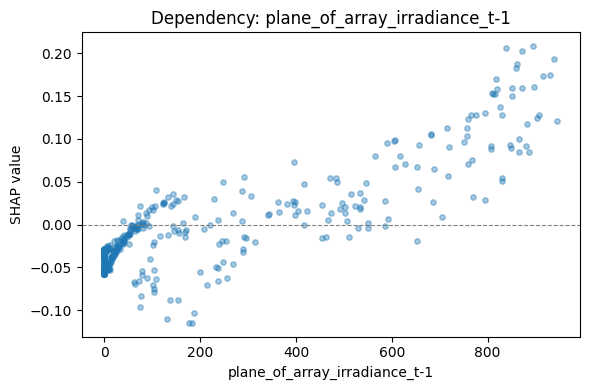

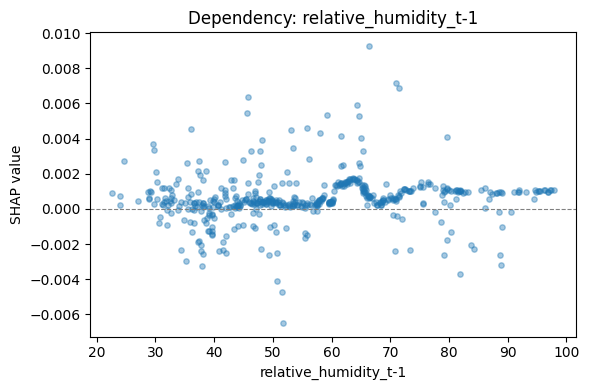

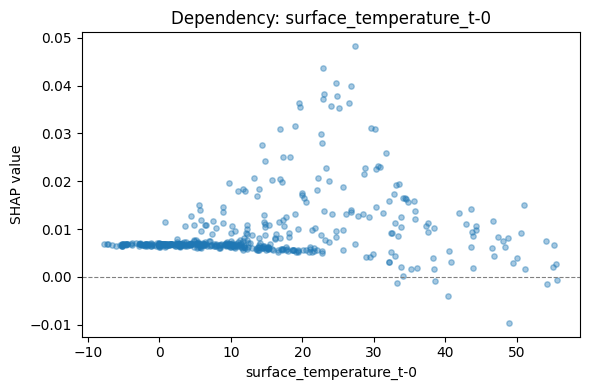

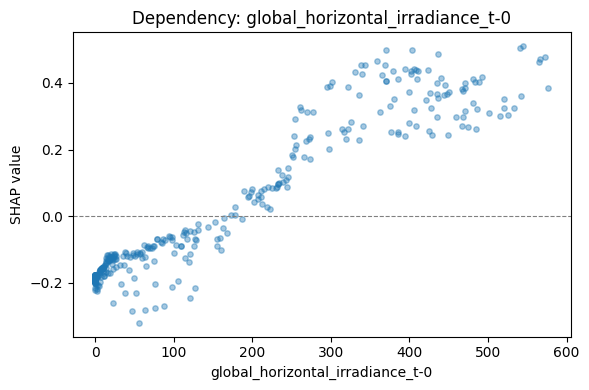

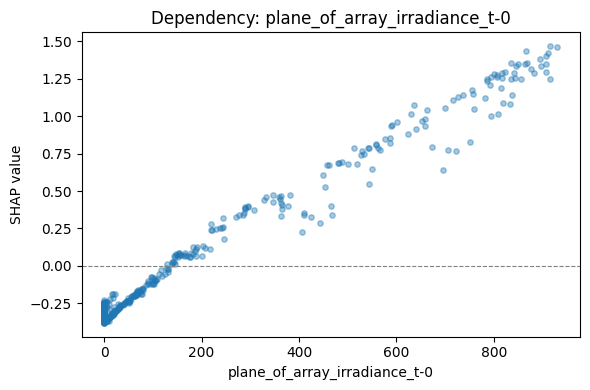

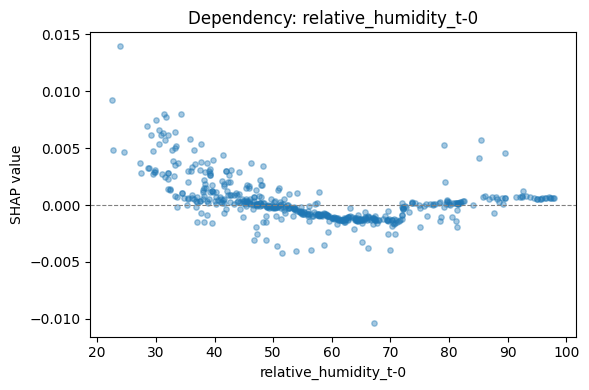

Saved: ./shap_dependency_points.xlsx (one sheet per feature: sample_id, feature_value, shap_value)
Saved: 64 dependency plots (shap_dependence_*.png)


In [14]:
# Dependency plot for every feature; save plot points to Excel (one sheet per feature)
if not HAS_SHAP:
    print("SHAP not available. Run the SHAP cell above first.")
else:
    def _excel_sheet_name(name, max_len=31):
        # Use short names for Excel sheets: GHI_t-0, POA_t-1, etc.
        abbr = {
            "global_horizontal_irradiance": "GHI",
            "plane_of_array_irradiance": "POA",
            "surface_temperature": "T_surf",
            "relative_humidity": "RH",
        }
        for long, short in abbr.items():
            if name.startswith(long + "_"):
                s = short + "_" + name[len(long) + 1 :]
                return s[:max_len] if len(s) > max_len else s
        s = "".join(c if c not in '\\/:*?"[]' else "_" for c in str(name))
        return s[:max_len] if len(s) > max_len else (s or "sheet")

    def _safe_filename(name):
        return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(name))

    n_features = shap_values.shape[1]
    dep_excel_path = os.path.join(SAVE_DIR, "shap_dependency_points.xlsx")

    with pd.ExcelWriter(dep_excel_path, engine="openpyxl") as writer:
        for i in range(n_features):
            x_vals = X_shap_raw[:, i]
            y_vals = shap_values[:, i]
            pts = pd.DataFrame({
                "sample_id": np.arange(len(x_vals)),
                "feature_value": x_vals,
                "shap_value": y_vals,
            })
            sheet_name = _excel_sheet_name(feature_names[i])
            pts.to_excel(writer, sheet_name=sheet_name, index=False)

            fig, ax = plt.subplots(figsize=(6, 4))
            ax.scatter(x_vals, y_vals, alpha=0.4, s=15)
            ax.set_xlabel(feature_names[i])
            ax.set_ylabel("SHAP value")
            ax.set_title(f"Dependency: {feature_names[i]}")
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
            plt.tight_layout()
            fname = _safe_filename(feature_names[i])
            plt.savefig(os.path.join(SAVE_DIR, f"shap_dependence_{fname}.png"), dpi=150, bbox_inches="tight")
            plt.show()
            plt.close()

    print(f"Saved: {dep_excel_path} (one sheet per feature: sample_id, feature_value, shap_value)")
    print(f"Saved: {n_features} dependency plots (shap_dependence_*.png)")